# Income Objective Portfolio Optimisation Under Volatility Regimes

This notebook develops an income-oriented equity portfolio optimisation model using Bursa Malaysia stocks. The analysis compares two portfolio universes:

- Stage 1: 10 low-volatility stocks
- Stage 2: Stage 1 stocks plus 5 high-volatility additions

The portfolio objective is income-oriented. Therefore, the model prioritises stable risk, controlled concentration, and consistent risk-adjusted performance instead of simply maximising return.

The optimisation uses constrained Mean-Variance Optimisation (MVO), where expected return is estimated using annualised mean log returns and portfolio risk is estimated using LedoitWolf shrinkage covariance. The income objective is implemented using a 10% annual volatility cap, 25% maximum asset cap, long-only weights, and full investment constraint.

The workflow follows these steps:

1. Configuration and assumptions
2. Risk-free rate calculation
3. Candidate pool and stock data collection
4. Data cleaning and log return calculation
5. Volatility classification
6. Individual stock metrics
7. Income objective portfolio optimisation
8. Model validation and justification checks
9. Visualisation and interpretation
10. Output export

## 1. Configuration and Assumptions

This section defines the main modelling assumptions used throughout the notebook. Keeping the configuration in one place improves reproducibility and avoids inconsistent parameter usage later in the analysis.

The portfolio objective is set to income. The income objective is represented using long-only allocation, a maximum asset weight cap, a volatility cap, and risk-adjusted performance evaluation.

In [ ]:
import pandas as pd
import numpy as np
import os

import yfinance as yf
from scipy.optimize import minimize
from sklearn.covariance import LedoitWolf

# -----------------------------
# General settings
# -----------------------------
ANNUALIZATION = 252
RANDOM_SEED = 2025
OBJECTIVE = "income"

np.random.seed(RANDOM_SEED)

# Benchmark setting
# Yahoo Finance ticker for FBMKLCI
BENCHMARK_TICKER = "^KLSE"

# In saved files and report tables, benchmark will be labelled as required by assignment
BENCHMARK_COL = "fbmklci"

# Income objective settings
# Asset cap controls concentration risk.
# 25% follows the tutorial-style income objective setting and prevents one stock
# from dominating the portfolio.
ASSET_CAP = 0.25

# Volatility cap represents the income objective's focus on stable risk.
# 10% follows the tutorial-style income objective setting.
VOL_CAP = 0.10

# Dividend yield is optional in the tutorial.
# It is not included here because the assignment focuses on daily closing prices,
# return, risk, beta, Sharpe ratio, and portfolio weights.
DIV_YIELD = None

# Analysis date range
START_DATE = "2023-05-22"
END_DATE = "2026-05-20"

# Folder paths
OUTPUT_DIR = "output"
RAW_DATA_DIR = "raw_data"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(RAW_DATA_DIR, exist_ok=True)

print("Configuration loaded successfully.")
print(f"Objective: {OBJECTIVE}")
print(f"Annualisation: {ANNUALIZATION} trading days")
print(f"Benchmark label: {BENCHMARK_COL}")
print(f"Asset cap: {ASSET_CAP:.0%}")
print(f"Volatility cap: {VOL_CAP:.0%}")
print(f"Date range: {START_DATE} to {END_DATE}")

Configuration loaded successfully.
Objective: income
Annualisation: 252 trading days
Benchmark label: fbmklci
Asset cap: 25%
Volatility cap: 10%
Date range: 2023-05-22 to 2026-05-20


## 2. Risk-Free Rate Calculation

The risk-free rate is estimated using Malaysia 3-Year Government Bond Yield data. The 3-year yield is used because the equity dataset covers approximately three years, so it provides a government-backed low-risk benchmark with a similar evaluation horizon.

Instead of assuming a fixed risk-free rate, monthly 3-year bond yield observations are averaged over the same period as the stock dataset. This makes the Sharpe ratio calculation more consistent with the interest-rate environment during the analysis period.

In [2]:
MGS_CSV = r"C:\Users\user\Documents\Y2S2\RBA\GroupRBA\data\3Year_MGS\Malaysia 3-Year Bond Yield Historical Data.csv"

# Load Malaysia 3-Year Government Bond Yield data
mgs = pd.read_csv(MGS_CSV)

# Clean column names
mgs.columns = mgs.columns.str.strip()

# Convert date and yield columns
mgs["Date"] = pd.to_datetime(mgs["Date"], errors="coerce")

# In the Investing.com file, the "Price" column represents the bond yield value.
mgs["Yield"] = pd.to_numeric(mgs["Price"], errors="coerce")

# Remove invalid rows
mgs = mgs.dropna(subset=["Date", "Yield"])

# Filter to match stock analysis period
mgs_period = mgs[
    (mgs["Date"] >= START_DATE) &
    (mgs["Date"] <= END_DATE)
].copy()

# Sort chronologically
mgs_period = mgs_period.sort_values("Date")

# Convert daily observations into monthly observations.
# The last available trading yield in each month is used.
mgs_period["Month"] = mgs_period["Date"].dt.to_period("M")

mgs_monthly = (
    mgs_period
    .sort_values("Date")
    .groupby("Month", as_index=False)
    .tail(1)
    .copy()
)

# Calculate average annual risk-free rate
RF_ANNUAL = mgs_monthly["Yield"].mean() / 100
RF_DAILY = RF_ANNUAL / ANNUALIZATION

# Single source of truth for all later calculations
RISK_FREE_RATE_ANNUAL = RF_ANNUAL
RISK_FREE_RATE_DAILY = RF_DAILY

print("Risk-Free Rate Source: Malaysia 3-Year Government Bond Yield")
print(f"Risk-free rate period: {mgs_period['Date'].min().date()} to {mgs_period['Date'].max().date()}")
print(f"Daily observations used before monthly conversion: {len(mgs_period)}")
print(f"Monthly observations used: {len(mgs_monthly)}")
print(f"Average annual risk-free rate: {RISK_FREE_RATE_ANNUAL:.4%}")
print(f"Daily risk-free rate: {RISK_FREE_RATE_DAILY:.6%}")

display(mgs_monthly[["Month", "Date", "Yield"]].reset_index(drop=True))

Risk-Free Rate Source: Malaysia 3-Year Government Bond Yield
Risk-free rate period: 2023-05-22 to 2026-05-20
Daily observations used before monthly conversion: 819
Monthly observations used: 37
Average annual risk-free rate: 3.3333%
Daily risk-free rate: 0.013227%


,Month,Date,Yield
0,2023-05,2023-05-31,3.409
1,2023-06,2023-06-30,3.505
2,2023-07,2023-07-31,3.497
3,2023-08,2023-08-31,3.491
4,2023-09,2023-09-29,3.570
5,2023-10,2023-10-31,3.665
6,2023-11,2023-11-30,3.508
7,2023-12,2023-12-29,3.470
8,2024-01,2024-01-31,3.397
9,2024-02,2024-02-29,3.466


# 3. SAVE RISK-FREE RATE OUTPUT

In [3]:
mgs_monthly[["Month", "Date", "Yield"]].to_csv(
    os.path.join(OUTPUT_DIR, "risk_free_rate_3year_mgs_monthly.csv"),
    index=False
)

risk_free_summary = pd.DataFrame({
    "Risk-Free Proxy": ["Malaysia 3-Year Government Bond Yield"],
    "Start Date": [START_DATE],
    "End Date": [END_DATE],
    "Average Annual Risk-Free Rate": [RISK_FREE_RATE_ANNUAL],
    "Daily Risk-Free Rate": [RISK_FREE_RATE_DAILY],
    "Monthly Observations": [len(mgs_monthly)]
})

risk_free_summary.to_csv(
    os.path.join(OUTPUT_DIR, "risk_free_rate_summary.csv"),
    index=False
)

display(risk_free_summary)

print("Risk-free rate outputs saved successfully.")

,Risk-Free Proxy,Start Date,End Date,Average Annual Risk-Free Rate,Daily Risk-Free Rate,Monthly Observations
0,Malaysia 3-Year Government Bond Yield,2023-05-22,2026-05-20,0.033333,0.000132,37


Risk-free rate outputs saved successfully.


# Phase 2
## 1. Candidate Pool and Stock Data Collection

This section defines the Bursa Malaysia candidate pool and downloads daily adjusted closing prices for the selected analysis period. The candidate pool includes a wider range of Bursa Malaysia stocks across sectors and market capitalisation groups to reduce selection bias.

FBMKLCI is included as the benchmark index and is renamed as fbmklci to match the assignment requirement.

In [4]:
stocks = [
    # Banks and financials
    "1155.KL", "1295.KL", "1023.KL", "5819.KL", "1066.KL",
    "1082.KL", "2488.KL", "1015.KL", "5185.KL", "1818.KL",

    # Utilities, telecom, infrastructure, energy
    "5347.KL", "6033.KL", "6742.KL", "6947.KL", "6888.KL",
    "7277.KL", "4677.KL", "4863.KL", "5210.KL", "5258.KL",

    # Healthcare and glove-related stocks
    "5225.KL", "5878.KL", "5168.KL", "7113.KL", "7106.KL",
    "7081.KL", "7148.KL",

    # Consumer, retail, defensive, plantation
    "4707.KL", "3816.KL", "6012.KL", "2445.KL", "1961.KL",
    "4065.KL", "7084.KL", "5296.KL", "5681.KL", "1562.KL",
    "3689.KL", "3026.KL",

    # Property, construction, industrials
    "5211.KL", "5288.KL", "5289.KL", "1619.KL", "4197.KL",
    "3182.KL", "4715.KL", "5398.KL", "3336.KL", "5099.KL",

    # Technology and higher-volatility candidates
    "0138.KL", "0166.KL", "0097.KL", "0128.KL", "5216.KL",
    "7203.KL", "5292.KL", "5306.KL", "0272.KL",

    # Additional Bursa candidates for wider screening
    "5285.KL", "5020.KL", "5008.KL", "5176.KL",
    "5236.KL", "5246.KL", "5250.KL", "5273.KL", "5297.KL",
    "5302.KL", "5309.KL", "5310.KL", "5318.KL", "5326.KL",
    "7047.KL", "7153.KL",
    "7191.KL", "7214.KL", "7223.KL", "7233.KL"
]

# Remove accidental duplicates while preserving order
stocks = list(dict.fromkeys(stocks))

print(f"Candidate pool size after removing duplicates: {len(stocks)} stocks")

# Download daily adjusted closing prices
print("Downloading 3 years of daily adjusted closing prices...")

raw_data = yf.download(
    stocks + [BENCHMARK_TICKER],
    start=START_DATE,
    end=END_DATE,
    auto_adjust=True,
    progress=True
)

# Extract adjusted closing prices
prices = raw_data["Close"].copy()

# Sort dates chronologically
prices = prices.sort_index()

# Remove columns that are completely missing
prices = prices.dropna(axis=1, how="all")

# Rename benchmark from Yahoo Finance ticker to assignment-required label
if BENCHMARK_TICKER not in prices.columns:
    raise ValueError("FBMKLCI benchmark was not downloaded. Please check benchmark ticker availability.")

prices = prices.rename(columns={BENCHMARK_TICKER: BENCHMARK_COL})

# Separate stock prices and benchmark prices
stock_prices_raw = prices.drop(columns=[BENCHMARK_COL]).copy()
benchmark_prices_raw = prices[BENCHMARK_COL].copy()

print("Download completed.")
print(f"Available stock price shape: {stock_prices_raw.shape}")
print(f"Benchmark observations: {benchmark_prices_raw.shape[0]}")
print(f"Successfully downloaded stocks: {len(stock_prices_raw.columns)}")

display(prices.head())

Candidate pool size after removing duplicates: 78 stocks


[*********************100%***********************]  79 of 79 completed

Download completed.
Available stock price shape: (738, 78)
Benchmark observations: 738
Successfully downloaded stocks: 78


Ticker,0097.KL,0128.KL,0138.KL,0166.KL,0272.KL,1015.KL,1023.KL,1066.KL,1082.KL,1155.KL,...,7113.KL,7148.KL,7153.KL,7191.KL,7203.KL,7214.KL,7223.KL,7233.KL,7277.KL,fbmklci
Date,,,,,,,,,,,,,,,,,,,,,
2023-05-22,7.804715,2.799701,0.730690,2.044185,1.05,3.013383,4.166173,4.496760,16.089142,7.160077,...,1.210321,1.333010,1.380230,0.509999,0.68837,0.457743,0.06,1.780888,2.003059,1419.000000
2023-05-23,7.794824,2.780258,0.716728,1.988687,1.06,2.962596,4.133174,4.504936,15.817978,7.185112,...,1.200400,1.360781,1.408208,0.505714,0.68375,0.462061,0.06,1.688134,2.012508,1411.540039
2023-05-24,7.765149,2.751095,0.712073,2.081185,1.01,2.971061,4.108424,4.464056,16.016832,7.143387,...,1.180559,1.323753,1.352253,0.497142,0.68375,0.457743,0.06,1.678858,2.040853,1409.619995
2023-05-25,7.715689,2.751095,0.712073,2.090434,1.01,2.962596,4.091925,4.464056,16.034910,7.143387,...,1.121035,1.323753,1.333601,0.488571,0.67913,0.466380,0.06,1.725236,1.984162,1402.479980
2023-05-26,7.666229,2.984404,0.726035,2.284678,1.05,2.954132,4.042425,4.464056,15.944523,7.160077,...,1.160717,1.323753,1.352253,0.492857,0.67913,0.470698,0.06,1.715960,1.955817,1402.979980


# 2. SAVE RAW DOWNLOADED PRICE DATA

These files support reproducibility and fulfil the dataset submission requirement.

In [5]:
candidate_pool = pd.Series(stocks, name="Candidate Pool")

candidate_pool.to_csv(
    os.path.join(OUTPUT_DIR, "candidate_pool.csv"),
    index=False
)

prices.to_csv(
    os.path.join(OUTPUT_DIR, "raw_downloaded_prices_with_fbmklci.csv")
)

stock_prices_raw.to_csv(
    os.path.join(OUTPUT_DIR, "raw_stock_prices.csv")
)

benchmark_prices_raw.to_csv(
    os.path.join(OUTPUT_DIR, "raw_fbmklci_prices.csv")
)

print("Raw downloaded price data saved successfully.")

Raw downloaded price data saved successfully.


# Phase 3
## 1. Data Cleaning and Alignment

This section cleans the downloaded price dataset and aligns all stocks with the FBMKLCI benchmark. Stocks with insufficient observations are removed to maintain data quality. The remaining series are arranged chronologically and aligned on the same trading dates before return calculation.

In [6]:
# Minimum observation threshold
# A 90% threshold keeps stocks with enough data while avoiding excessive loss of the candidate pool.
minimum_required_observations = int(len(stock_prices_raw) * 0.90)

stock_prices_clean = stock_prices_raw.dropna(
    axis=1,
    thresh=minimum_required_observations
).copy()

# Combine cleaned stock prices with benchmark
cleaned_prices = pd.concat(
    [stock_prices_clean, benchmark_prices_raw.rename(BENCHMARK_COL)],
    axis=1
)

# Drop rows where benchmark is missing
cleaned_prices = cleaned_prices.dropna(subset=[BENCHMARK_COL])

# Drop any remaining rows with missing stock prices
# This ensures all selected assets are aligned on the same trading dates.
cleaned_prices = cleaned_prices.dropna(how="any")

# Separate cleaned stock prices and benchmark
stock_prices_clean = cleaned_prices.drop(columns=[BENCHMARK_COL])
benchmark_prices_clean = cleaned_prices[BENCHMARK_COL]

print(f"Remaining stocks after cleaning: {len(stock_prices_clean.columns)}")
print(stock_prices_clean.columns.tolist())

print(f"\nCleaned price dataset shape including benchmark: {cleaned_prices.shape}")
print(f"Date range: {cleaned_prices.index.min().date()} to {cleaned_prices.index.max().date()}")

display(cleaned_prices.head())

Remaining stocks after cleaning: 77
['0097.KL', '0128.KL', '0138.KL', '0166.KL', '0272.KL', '1015.KL', '1023.KL', '1066.KL', '1082.KL', '1155.KL', '1295.KL', '1562.KL', '1619.KL', '1818.KL', '1961.KL', '2445.KL', '2488.KL', '3026.KL', '3182.KL', '3336.KL', '3689.KL', '3816.KL', '4065.KL', '4197.KL', '4677.KL', '4707.KL', '4715.KL', '4863.KL', '5008.KL', '5020.KL', '5099.KL', '5168.KL', '5176.KL', '5185.KL', '5210.KL', '5211.KL', '5216.KL', '5225.KL', '5236.KL', '5246.KL', '5250.KL', '5258.KL', '5273.KL', '5285.KL', '5288.KL', '5289.KL', '5292.KL', '5296.KL', '5297.KL', '5302.KL', '5306.KL', '5309.KL', '5310.KL', '5318.KL', '5347.KL', '5398.KL', '5681.KL', '5819.KL', '5878.KL', '6012.KL', '6033.KL', '6742.KL', '6888.KL', '6947.KL', '7047.KL', '7081.KL', '7084.KL', '7106.KL', '7113.KL', '7148.KL', '7153.KL', '7191.KL', '7203.KL', '7214.KL', '7223.KL', '7233.KL', '7277.KL']

Cleaned price dataset shape including benchmark: (736, 78)
Date range: 2023-05-22 to 2026-05-19


,0097.KL,0128.KL,0138.KL,0166.KL,0272.KL,1015.KL,1023.KL,1066.KL,1082.KL,1155.KL,...,7113.KL,7148.KL,7153.KL,7191.KL,7203.KL,7214.KL,7223.KL,7233.KL,7277.KL,fbmklci
Date,,,,,,,,,,,,,,,,,,,,,
2023-05-22,7.804715,2.799701,0.730690,2.044185,1.05,3.013383,4.166173,4.496760,16.089142,7.160077,...,1.210321,1.333010,1.380230,0.509999,0.68837,0.457743,0.06,1.780888,2.003059,1419.000000
2023-05-23,7.794824,2.780258,0.716728,1.988687,1.06,2.962596,4.133174,4.504936,15.817978,7.185112,...,1.200400,1.360781,1.408208,0.505714,0.68375,0.462061,0.06,1.688134,2.012508,1411.540039
2023-05-24,7.765149,2.751095,0.712073,2.081185,1.01,2.971061,4.108424,4.464056,16.016832,7.143387,...,1.180559,1.323753,1.352253,0.497142,0.68375,0.457743,0.06,1.678858,2.040853,1409.619995
2023-05-25,7.715689,2.751095,0.712073,2.090434,1.01,2.962596,4.091925,4.464056,16.034910,7.143387,...,1.121035,1.323753,1.333601,0.488571,0.67913,0.466380,0.06,1.725236,1.984162,1402.479980
2023-05-26,7.666229,2.984404,0.726035,2.284678,1.05,2.954132,4.042425,4.464056,15.944523,7.160077,...,1.160717,1.323753,1.352253,0.492857,0.67913,0.470698,0.06,1.715960,1.955817,1402.979980


## 2. Log Return Calculation

Daily log returns are computed using the formula:

rₜ = ln(Pₜ / Pₜ₋₁)

Where:
- rₜ = daily log return at time t
- Pₜ = closing price at time t
- Pₜ₋₁ = closing price on the previous trading day
- ln = natural logarithm

Log returns are used because they are suitable for time-series financial analysis and are required by the assignment rubric.

In [7]:
# Compute daily log returns for stocks and benchmark
returns = np.log(stock_prices_clean / stock_prices_clean.shift(1)).dropna(how="any")
benchmark_returns = np.log(benchmark_prices_clean / benchmark_prices_clean.shift(1)).dropna()

# Align stock returns and benchmark returns on common dates
common_dates = returns.index.intersection(benchmark_returns.index)

returns = returns.loc[common_dates]
benchmark_returns = benchmark_returns.loc[common_dates]

# Combine stock returns with benchmark for export
returns_with_benchmark = pd.concat(
    [returns, benchmark_returns.rename(BENCHMARK_COL)],
    axis=1
)

print(f"Stock log return dataset shape: {returns.shape}")
print(f"Benchmark log return observations: {len(benchmark_returns)}")
print(f"Date range: {returns.index.min().date()} to {returns.index.max().date()}")

display(returns_with_benchmark.head())

Stock log return dataset shape: (735, 77)
Benchmark log return observations: 735
Date range: 2023-05-23 to 2026-05-19


,0097.KL,0128.KL,0138.KL,0166.KL,0272.KL,1015.KL,1023.KL,1066.KL,1082.KL,1155.KL,...,7113.KL,7148.KL,7153.KL,7191.KL,7203.KL,7214.KL,7223.KL,7233.KL,7277.KL,fbmklci
Date,,,,,,,,,,,,,,,,,,,,,
2023-05-23,-0.001268,-0.006969,-0.019293,-0.027525,0.009479,-0.016997,-0.007952,0.001817,-0.016997,0.003490,...,-0.008230,0.020619,0.020068,-0.008437,-0.006734,0.009390,0.0,-0.053489,0.004706,-0.005271
2023-05-24,-0.003814,-0.010545,-0.006515,0.045463,-0.048319,0.002853,-0.006006,-0.009116,0.012493,-0.005824,...,-0.016667,-0.027588,-0.040546,-0.017096,0.000000,-0.009390,0.0,-0.005510,0.013986,-0.001361
2023-05-25,-0.006390,0.000000,0.000000,0.004434,0.000000,-0.002853,-0.004024,0.000000,0.001128,0.000000,...,-0.051736,0.000000,-0.013889,-0.017391,-0.006780,0.018692,0.0,0.027250,-0.028171,-0.005078
2023-05-26,-0.006431,0.081401,0.019418,0.088853,0.038840,-0.002861,-0.012171,0.000000,-0.005653,0.002334,...,0.034786,0.000000,0.013889,0.008734,0.000000,0.009217,0.0,-0.005391,-0.014389,0.000356
2023-05-29,0.016635,0.028895,0.000000,0.000000,0.018869,0.005714,-0.002043,-0.003670,0.002265,0.002328,...,-0.008584,-0.021202,-0.006920,-0.017546,-0.020619,-0.027909,0.0,0.058998,0.019139,0.001389


## 3. SAVE CLEANED DATA AND RETURNS

In [8]:
cleaned_prices.to_csv(
    os.path.join(OUTPUT_DIR, "cleaned_prices_with_fbmklci.csv")
)

stock_prices_clean.to_csv(
    os.path.join(OUTPUT_DIR, "cleaned_stock_prices.csv")
)

benchmark_prices_clean.to_csv(
    os.path.join(OUTPUT_DIR, "cleaned_fbmklci_prices.csv")
)

returns.to_csv(
    os.path.join(OUTPUT_DIR, "log_returns_stocks.csv")
)

benchmark_returns.rename(BENCHMARK_COL).to_csv(
    os.path.join(OUTPUT_DIR, "log_returns_fbmklci.csv")
)

returns_with_benchmark.to_csv(
    os.path.join(OUTPUT_DIR, "log_returns_with_fbmklci.csv")
)

print("Cleaned prices and log returns saved successfully.")

Cleaned prices and log returns saved successfully.


# Phase 4
## 1. Daily Statistics and Volatility Classification

This section calculates the daily mean log return and daily volatility for each stock in the cleaned candidate pool. These statistics are then used to classify stocks into Stage 1 and Stage 2.

Stage 1 follows the assignment rule by first testing whether daily mean return is greater than daily volatility. If fewer than 10 stocks satisfy the strict rule, a stabiliser is applied by selecting positive-return stocks with the lowest volatility.

Stage 2 follows the assignment rule by selecting stocks where daily volatility is greater than three times daily mean return. A positive-return condition is also applied so that the high-volatility additions remain suitable for an income-oriented investor advisory.

In [9]:
# Calculate daily statistics from log returns
mean_returns = returns.mean()
volatility = returns.std()

stats_full = pd.DataFrame({
    "Mean Return": mean_returns,
    "Volatility": volatility,
    "Annual Return": mean_returns * ANNUALIZATION,
    "Annual Risk": volatility * np.sqrt(ANNUALIZATION)
})

# Remove zero-volatility stocks, if any
stats_full = stats_full[stats_full["Volatility"] > 0].copy()

# Return/Risk Ratio is used as a supporting diagnostic only
stats_full["Return/Risk Ratio"] = stats_full["Mean Return"] / stats_full["Volatility"]

print(f"Total valid stocks for classification: {len(stats_full)}")
display(stats_full.head())

Total valid stocks for classification: 77


,Mean Return,Volatility,Annual Return,Annual Risk,Return/Risk Ratio
0097.KL,-0.000313,0.035549,-0.078918,0.564323,-0.008809
0128.KL,0.000708,0.021312,0.178346,0.338321,0.033207
0138.KL,0.000182,0.024924,0.045752,0.395664,0.007284
0166.KL,-0.000114,0.027491,-0.028707,0.436409,-0.004144
0272.KL,-0.001495,0.044066,-0.376667,0.699533,-0.033919


## 2. Stage 1 Low-Volatility Stock Selection

The strict Stage 1 rule is tested first:

daily mean return > daily volatility

If the strict rule does not produce enough stocks, the stabiliser selects positive-return stocks with the lowest daily volatility. This keeps the Stage 1 universe aligned with the income objective because the selected stocks have positive historical return behaviour and relatively stable risk.

In [10]:
# Stage 1 selection
stats_positive = stats_full[stats_full["Mean Return"] > 0].copy()

print(f"Stocks with positive mean returns: {len(stats_positive)}")
print(f"Stocks excluded due to negative mean returns: {len(stats_full) - len(stats_positive)}")

# Test strict assignment condition
low_vol_condition = stats_positive[
    stats_positive["Mean Return"] > stats_positive["Volatility"]
].copy()

print(f"Stocks satisfying strict Stage 1 rule: {len(low_vol_condition)}")

if len(low_vol_condition) >= 10:
    low_vol = low_vol_condition.sort_values(
        by="Volatility",
        ascending=True
    ).head(10).copy()

    stage1_method = "Strict assignment rule: Mean Return > Volatility"

else:
    print("Fewer than 10 stocks met the strict Stage 1 rule.")
    print("Applying stabiliser: positive-return stocks with lowest volatility.")

    low_vol = stats_positive.sort_values(
        by="Volatility",
        ascending=True
    ).head(10).copy()

    stage1_method = "Stabiliser: positive-return stocks with lowest volatility"

low_vol["Selection Method"] = stage1_method

print("\nStage 1 Low-Volatility Stocks:")
display(low_vol[[
    "Mean Return",
    "Volatility",
    "Annual Return",
    "Annual Risk",
    "Return/Risk Ratio"
]].round(6))

Stocks with positive mean returns: 45
Stocks excluded due to negative mean returns: 32
Stocks satisfying strict Stage 1 rule: 0
Fewer than 10 stocks met the strict Stage 1 rule.
Applying stabiliser: positive-return stocks with lowest volatility.

Stage 1 Low-Volatility Stocks:


,Mean Return,Volatility,Annual Return,Annual Risk,Return/Risk Ratio
1155.KL,0.000594,0.007737,0.149699,0.122822,0.076779
1066.KL,0.000826,0.008862,0.208065,0.140687,0.093163
5819.KL,0.000266,0.009342,0.067094,0.148305,0.028499
6033.KL,0.000225,0.009580,0.056794,0.152081,0.023525
5225.KL,0.000641,0.009675,0.161534,0.153587,0.066254
1082.KL,0.000197,0.009894,0.049720,0.157068,0.019941
1818.KL,0.000601,0.010275,0.151500,0.163114,0.058509
1295.KL,0.000453,0.010413,0.114208,0.165301,0.043523
5347.KL,0.000723,0.010698,0.182131,0.169832,0.067556
3816.KL,0.000340,0.010789,0.085661,0.171274,0.031506


## 3. Stage 2 High-Volatility Stock Selection

Stage 2 adds five high-volatility stocks to the Stage 1 universe. The high-volatility rule is:

daily volatility > 3 × daily mean return

A positive-return condition is also applied to avoid adding stocks with negative historical return behaviour. This keeps the expanded universe more suitable for an income-oriented portfolio comparison.

In [11]:
# Stage 2 high-volatility selection
high_vol_candidates = stats_full[
    (stats_full["Volatility"] > 3 * stats_full["Mean Return"]) &
    (stats_full["Mean Return"] > 0)
].copy()

print(f"Positive-return stocks satisfying Stage 2 high-volatility rule: {len(high_vol_candidates)}")

if len(high_vol_candidates) >= 5:
    high_vol = high_vol_candidates.sort_values(
        by="Volatility",
        ascending=False
    ).head(5).copy()

    stage2_method = "Assignment high-volatility rule with positive-return stabiliser"

else:
    print("Fewer than 5 positive-return stocks met the high-volatility rule.")
    print("Applying stabiliser: highest-volatility positive-return stocks.")

    high_vol = stats_positive.sort_values(
        by="Volatility",
        ascending=False
    ).head(5).copy()

    stage2_method = "Stabiliser: highest-volatility positive-return stocks"

high_vol["Meets High-Vol Rule"] = high_vol["Volatility"] > 3 * high_vol["Mean Return"]
high_vol["Selection Method"] = stage2_method

print("\nStage 2 High-Volatility Additions:")
display(high_vol[[
    "Mean Return",
    "Volatility",
    "Annual Return",
    "Annual Risk",
    "Return/Risk Ratio",
    "Meets High-Vol Rule"
]].round(6))

Positive-return stocks satisfying Stage 2 high-volatility rule: 45

Stage 2 High-Volatility Additions:


,Mean Return,Volatility,Annual Return,Annual Risk,Return/Risk Ratio,Meets High-Vol Rule
5297.KL,0.000164,0.037452,0.041415,0.594535,0.004388,True
5292.KL,0.000829,0.029854,0.208963,0.473920,0.027776,True
4677.KL,0.001470,0.029238,0.370489,0.464131,0.050284,True
6742.KL,0.001799,0.026823,0.453236,0.425797,0.067053,True
5288.KL,0.001706,0.025397,0.429833,0.403171,0.067160,True


## 4. Final Stage 1 and Stage 2 Universes

Stage 1 contains the 10 low-volatility stocks. Stage 2 expands the universe by adding 5 high-volatility stocks to the Stage 1 list. The Stage 2 portfolio therefore tests whether adding higher-risk stocks improves or weakens portfolio quality under the income objective.

In [12]:
# Final selected universes
stage1_stocks = list(low_vol.index)
stage2_additions = list(high_vol.index)
stage2_stocks = stage1_stocks + stage2_additions

print("Stage 1 Low-Volatility Universe:")
print(stage1_stocks)

print("\nStage 2 High-Volatility Additions:")
print(stage2_additions)

print("\nStage 2 Full Universe:")
print(stage2_stocks)

print(f"\nStage 1 size: {len(stage1_stocks)}")
print(f"Stage 2 size: {len(stage2_stocks)}")

# Stage-specific return datasets
returns_stage1 = returns[stage1_stocks].copy()
returns_stage2 = returns[stage2_stocks].copy()

Stage 1 Low-Volatility Universe:
['1155.KL', '1066.KL', '5819.KL', '6033.KL', '5225.KL', '1082.KL', '1818.KL', '1295.KL', '5347.KL', '3816.KL']

Stage 2 High-Volatility Additions:
['5297.KL', '5292.KL', '4677.KL', '6742.KL', '5288.KL']

Stage 2 Full Universe:
['1155.KL', '1066.KL', '5819.KL', '6033.KL', '5225.KL', '1082.KL', '1818.KL', '1295.KL', '5347.KL', '3816.KL', '5297.KL', '5292.KL', '4677.KL', '6742.KL', '5288.KL']

Stage 1 size: 10
Stage 2 size: 15


## 5. Save Volatility Classification Outputs

The selected stocks, classification results, and stage-specific return datasets are saved to support reproducibility and later portfolio optimisation.

In [13]:
# Save volatility classification outputs
stats_full.to_csv(
    os.path.join(OUTPUT_DIR, "stock_statistics_full.csv")
)

low_vol.to_csv(
    os.path.join(OUTPUT_DIR, "stage1_low_vol_stocks.csv")
)

high_vol.to_csv(
    os.path.join(OUTPUT_DIR, "stage2_high_vol_additions.csv")
)

pd.Series(stage1_stocks, name="Stage 1 Stocks").to_csv(
    os.path.join(OUTPUT_DIR, "stage1_stocks.csv"),
    index=False
)

pd.Series(stage2_additions, name="Stage 2 Additions").to_csv(
    os.path.join(OUTPUT_DIR, "stage2_additions.csv"),
    index=False
)

pd.Series(stage2_stocks, name="Stage 2 Full Universe").to_csv(
    os.path.join(OUTPUT_DIR, "stage2_stocks.csv"),
    index=False
)

returns_stage1.to_csv(
    os.path.join(OUTPUT_DIR, "log_returns_stage1.csv")
)

returns_stage2.to_csv(
    os.path.join(OUTPUT_DIR, "log_returns_stage2.csv")
)

print("Volatility classification outputs saved successfully.")

Volatility classification outputs saved successfully.


# Phase 5
## 1. Individual Stock Metrics

This section calculates individual stock performance measures for the selected Stage 1 and Stage 2 stocks. The metrics include annual return, annual risk, beta against FBMKLCI, Sharpe ratio, and return-risk ratio.

The Sharpe ratio uses the calculated average 3-year MGS yield as the annual risk-free rate.

In [14]:
# Calculate beta against FBMKLCI
def calculate_beta(stock_returns, market_returns):
    """
    Calculate beta of one stock against the market benchmark.

    Beta = Cov(stock return, market return) / Var(market return)
    """
    aligned = pd.concat([stock_returns, market_returns], axis=1).dropna()
    aligned.columns = ["stock", "market"]

    covariance = aligned["stock"].cov(aligned["market"])
    market_variance = aligned["market"].var()

    return covariance / market_variance


beta_values = {}

for ticker in stage2_stocks:
    beta_values[ticker] = calculate_beta(
        returns_stage2[ticker],
        benchmark_returns
    )

beta = pd.Series(beta_values, name="Beta vs FBMKLCI")

print("Beta vs FBMKLCI:")
display(beta.round(4))

Beta vs FBMKLCI:


1155.KL    0.8267
1066.KL    0.7893
5819.KL    0.7916
6033.KL    0.5345
5225.KL    0.5686
1082.KL    0.7033
1818.KL    0.6863
1295.KL    1.0792
5347.KL    0.9535
3816.KL    0.6440
5297.KL    1.0166
5292.KL    1.6705
4677.KL    1.8235
6742.KL    1.6742
5288.KL    1.8539
Name: Beta vs FBMKLCI, dtype: float64

In [15]:
# Build individual stock metrics table
individual_metrics = stats_full.loc[stage2_stocks].copy()

# Add beta values
individual_metrics["Beta vs FBMKLCI"] = beta

# Calculate Sharpe ratio using calculated risk-free rate
individual_metrics["Sharpe Ratio"] = (
    (individual_metrics["Annual Return"] - RISK_FREE_RATE_ANNUAL) /
    individual_metrics["Annual Risk"]
)

# Add stage label
individual_metrics["Stage"] = [
    "Stage 1 Low Volatility" if ticker in stage1_stocks
    else "Stage 2 High Volatility Addition"
    for ticker in individual_metrics.index
]

# Reorder columns
individual_metrics = individual_metrics[
    [
        "Stage",
        "Mean Return",
        "Volatility",
        "Annual Return",
        "Annual Risk",
        "Beta vs FBMKLCI",
        "Sharpe Ratio",
        "Return/Risk Ratio"
    ]
]

print("Individual Stock Metrics:")
display(individual_metrics.round(4))

print("Stage 1 Individual Stock Metrics:")
display(individual_metrics.loc[stage1_stocks].round(4))

print("Stage 2 High-Volatility Addition Metrics:")
display(individual_metrics.loc[stage2_additions].round(4))

Individual Stock Metrics:


,Stage,Mean Return,Volatility,Annual Return,Annual Risk,Beta vs FBMKLCI,Sharpe Ratio,Return/Risk Ratio
1155.KL,Stage 1 Low Volatility,0.0006,0.0077,0.1497,0.1228,0.8267,0.9474,0.0768
1066.KL,Stage 1 Low Volatility,0.0008,0.0089,0.2081,0.1407,0.7893,1.2420,0.0932
5819.KL,Stage 1 Low Volatility,0.0003,0.0093,0.0671,0.1483,0.7916,0.2276,0.0285
6033.KL,Stage 1 Low Volatility,0.0002,0.0096,0.0568,0.1521,0.5345,0.1543,0.0235
5225.KL,Stage 1 Low Volatility,0.0006,0.0097,0.1615,0.1536,0.5686,0.8347,0.0663
1082.KL,Stage 1 Low Volatility,0.0002,0.0099,0.0497,0.1571,0.7033,0.1043,0.0199
1818.KL,Stage 1 Low Volatility,0.0006,0.0103,0.1515,0.1631,0.6863,0.7244,0.0585
1295.KL,Stage 1 Low Volatility,0.0005,0.0104,0.1142,0.1653,1.0792,0.4893,0.0435
5347.KL,Stage 1 Low Volatility,0.0007,0.0107,0.1821,0.1698,0.9535,0.8761,0.0676
3816.KL,Stage 1 Low Volatility,0.0003,0.0108,0.0857,0.1713,0.6440,0.3055,0.0315


Stage 1 Individual Stock Metrics:


,Stage,Mean Return,Volatility,Annual Return,Annual Risk,Beta vs FBMKLCI,Sharpe Ratio,Return/Risk Ratio
1155.KL,Stage 1 Low Volatility,0.0006,0.0077,0.1497,0.1228,0.8267,0.9474,0.0768
1066.KL,Stage 1 Low Volatility,0.0008,0.0089,0.2081,0.1407,0.7893,1.2420,0.0932
5819.KL,Stage 1 Low Volatility,0.0003,0.0093,0.0671,0.1483,0.7916,0.2276,0.0285
6033.KL,Stage 1 Low Volatility,0.0002,0.0096,0.0568,0.1521,0.5345,0.1543,0.0235
5225.KL,Stage 1 Low Volatility,0.0006,0.0097,0.1615,0.1536,0.5686,0.8347,0.0663
1082.KL,Stage 1 Low Volatility,0.0002,0.0099,0.0497,0.1571,0.7033,0.1043,0.0199
1818.KL,Stage 1 Low Volatility,0.0006,0.0103,0.1515,0.1631,0.6863,0.7244,0.0585
1295.KL,Stage 1 Low Volatility,0.0005,0.0104,0.1142,0.1653,1.0792,0.4893,0.0435
5347.KL,Stage 1 Low Volatility,0.0007,0.0107,0.1821,0.1698,0.9535,0.8761,0.0676
3816.KL,Stage 1 Low Volatility,0.0003,0.0108,0.0857,0.1713,0.6440,0.3055,0.0315


Stage 2 High-Volatility Addition Metrics:


,Stage,Mean Return,Volatility,Annual Return,Annual Risk,Beta vs FBMKLCI,Sharpe Ratio,Return/Risk Ratio
5297.KL,Stage 2 High Volatility Addition,0.0002,0.0375,0.0414,0.5945,1.0166,0.0136,0.0044
5292.KL,Stage 2 High Volatility Addition,0.0008,0.0299,0.2090,0.4739,1.6705,0.3706,0.0278
4677.KL,Stage 2 High Volatility Addition,0.0015,0.0292,0.3705,0.4641,1.8235,0.7264,0.0503
6742.KL,Stage 2 High Volatility Addition,0.0018,0.0268,0.4532,0.4258,1.6742,0.9862,0.0671
5288.KL,Stage 2 High Volatility Addition,0.0017,0.0254,0.4298,0.4032,1.8539,0.9835,0.0672


## 2. Correlation Analysis

Correlation is used to examine how selected stocks move together. This is important because portfolio risk depends not only on each stock's individual volatility, but also on how the stocks interact with each other.

Lower or moderate correlations may support diversification, while highly correlated stocks may reduce diversification benefits.

In [16]:
# Correlation matrices
correlation_stage1 = returns_stage1.corr()
correlation_stage2 = returns_stage2.corr()

print("Stage 1 Correlation Matrix:")
display(correlation_stage1.round(3))

print("Stage 2 Correlation Matrix:")
display(correlation_stage2.round(3))

Stage 1 Correlation Matrix:


,1155.KL,1066.KL,5819.KL,6033.KL,5225.KL,1082.KL,1818.KL,1295.KL,5347.KL,3816.KL
1155.KL,1.000,0.541,0.488,0.227,0.229,0.381,0.364,0.505,0.301,0.183
1066.KL,0.541,1.000,0.534,0.213,0.230,0.358,0.278,0.456,0.258,0.117
5819.KL,0.488,0.534,1.000,0.252,0.225,0.479,0.320,0.440,0.239,0.096
6033.KL,0.227,0.213,0.252,1.000,0.174,0.154,0.085,0.236,0.121,0.216
5225.KL,0.229,0.230,0.225,0.174,1.000,0.138,0.167,0.239,0.203,0.042
1082.KL,0.381,0.358,0.479,0.154,0.138,1.000,0.300,0.331,0.210,0.158
1818.KL,0.364,0.278,0.320,0.085,0.167,0.300,1.000,0.255,0.280,0.165
1295.KL,0.505,0.456,0.440,0.236,0.239,0.331,0.255,1.000,0.296,0.152
5347.KL,0.301,0.258,0.239,0.121,0.203,0.210,0.280,0.296,1.000,0.130
3816.KL,0.183,0.117,0.096,0.216,0.042,0.158,0.165,0.152,0.130,1.000


Stage 2 Correlation Matrix:


,1155.KL,1066.KL,5819.KL,6033.KL,5225.KL,1082.KL,1818.KL,1295.KL,5347.KL,3816.KL,5297.KL,5292.KL,4677.KL,6742.KL,5288.KL
1155.KL,1.000,0.541,0.488,0.227,0.229,0.381,0.364,0.505,0.301,0.183,0.133,0.206,0.152,0.137,0.285
1066.KL,0.541,1.000,0.534,0.213,0.230,0.358,0.278,0.456,0.258,0.117,0.107,0.178,0.116,0.138,0.227
5819.KL,0.488,0.534,1.000,0.252,0.225,0.479,0.320,0.440,0.239,0.096,0.092,0.147,0.124,0.101,0.197
6033.KL,0.227,0.213,0.252,1.000,0.174,0.154,0.085,0.236,0.121,0.216,0.120,0.142,0.165,0.126,0.107
5225.KL,0.229,0.230,0.225,0.174,1.000,0.138,0.167,0.239,0.203,0.042,0.070,0.038,0.085,0.048,0.192
1082.KL,0.381,0.358,0.479,0.154,0.138,1.000,0.300,0.331,0.210,0.158,0.118,0.162,0.126,0.140,0.164
1818.KL,0.364,0.278,0.320,0.085,0.167,0.300,1.000,0.255,0.280,0.165,0.099,0.211,0.195,0.184,0.302
1295.KL,0.505,0.456,0.440,0.236,0.239,0.331,0.255,1.000,0.296,0.152,0.080,0.189,0.151,0.143,0.275
5347.KL,0.301,0.258,0.239,0.121,0.203,0.210,0.280,0.296,1.000,0.130,0.031,0.205,0.207,0.255,0.308
3816.KL,0.183,0.117,0.096,0.216,0.042,0.158,0.165,0.152,0.130,1.000,0.142,0.211,0.172,0.173,0.154


## 3. Save Individual Metrics Outputs

The individual stock metrics and correlation matrices are saved for reporting and reproducibility.

In [17]:
# Save Phase 5 outputs
individual_metrics.to_csv(
    os.path.join(OUTPUT_DIR, "individual_stock_metrics.csv")
)

individual_metrics.loc[stage1_stocks].to_csv(
    os.path.join(OUTPUT_DIR, "stage1_individual_metrics.csv")
)

individual_metrics.loc[stage2_additions].to_csv(
    os.path.join(OUTPUT_DIR, "stage2_addition_metrics.csv")
)

correlation_stage1.to_csv(
    os.path.join(OUTPUT_DIR, "correlation_stage1.csv")
)

correlation_stage2.to_csv(
    os.path.join(OUTPUT_DIR, "correlation_stage2.csv")
)

beta.to_csv(
    os.path.join(OUTPUT_DIR, "beta_vs_fbmklci.csv")
)

print("Individual stock metrics and correlation outputs saved successfully.")

Individual stock metrics and correlation outputs saved successfully.


### Phase 5 Summary Interpretation

The Stage 1 stocks show a defensive profile that fits the income objective. Most Stage 1 stocks have positive annual returns, moderate annual risk, and beta values below 1, meaning they are generally less sensitive to FBMKLCI movements. Among them, 1066.KL, 1155.KL, 5347.KL, and 5225.KL show stronger Sharpe ratios, making them more attractive low-volatility income candidates.

The Stage 2 additions introduce a higher-risk opportunity set. These stocks have higher annual risk and mostly higher beta values, but they also maintain positive annual returns. This makes them suitable for testing whether selected high-volatility stocks can improve the optimised portfolio without relying on negative-return assets.

The correlation results show why optimisation is needed. Stage 1 contains some moderate correlations among financial stocks, while several Stage 2 additions have relatively low correlation with the defensive stocks. However, 4677.KL and 6742.KL have a high correlation of 0.796, so the optimiser should not automatically allocate to both if one already provides similar exposure.

# Phase 6
## 1. Income Objective Portfolio Optimisation

This phase applies constrained Mean-Variance Optimisation (MVO) to construct the Stage 1 and Stage 2 income portfolios.

The model uses annualised mean log returns as the expected return input and LedoitWolf shrinkage covariance as the risk input. This keeps the optimisation aligned with MVO while improving covariance stability.

The income objective is represented through these constraints:

- Long-only portfolio, so short selling is not allowed
- Fully invested portfolio, so weights must sum to 100%
- 25% maximum asset cap to control concentration risk
- 10% annual volatility cap to maintain stable risk

The optimisation first checks the minimum-volatility feasible portfolio. It then maximises annual return while keeping annual risk within the 10% income volatility cap. Sharpe ratio is calculated after optimisation as a performance evaluation metric.

## 2. MVO Risk Input: LedoitWolf Shrinkage Covariance
This function estimates the annualised covariance matrix used to measure portfolio risk in the MVO framework.


In [18]:
def ledoit_wolf_covariance(returns_data):
    """
    Estimate annualised LedoitWolf shrinkage covariance matrix.

    LedoitWolf shrinkage is used because sample covariance can be noisy,
    especially when many assets are included. Shrinkage improves stability
    for portfolio optimisation.
    """
    lw = LedoitWolf()
    lw.fit(returns_data.values)

    cov_daily = lw.covariance_
    cov_annual = cov_daily * ANNUALIZATION

    return pd.DataFrame(
        cov_annual,
        index=returns_data.columns,
        columns=returns_data.columns
    )

## 3. MVO Portfolio Performance Function
This function calculates annual return, annual risk, Sharpe ratio, and beta for a given set of portfolio weights.


In [19]:
def portfolio_performance(weights, returns_data, cov_annual, beta_values):
    """
    Calculate annual portfolio return, annual risk, Sharpe ratio, and beta.
    """
    weights = np.array(weights)

    mean_annual_returns = returns_data.mean() * ANNUALIZATION

    portfolio_return = np.dot(weights, mean_annual_returns)

    portfolio_risk = np.sqrt(
        weights.T @ cov_annual.values @ weights
    )

    portfolio_sharpe = (
        (portfolio_return - RISK_FREE_RATE_ANNUAL) / portfolio_risk
        if portfolio_risk > 0
        else np.nan
    )

    portfolio_beta = np.dot(
        weights,
        beta_values.loc[returns_data.columns]
    )

    return {
        "Annual Return": portfolio_return,
        "Annual Risk": portfolio_risk,
        "Sharpe Ratio": portfolio_sharpe,
        "Beta vs FBMKLCI": portfolio_beta
    }

## 4. MVO Minimum-Volatility Feasibility Check
This function checks whether the 10% income volatility cap is feasible under the long-only and asset-cap constraints.


In [20]:
def minimise_volatility_portfolio(returns_data, beta_values, max_weight=ASSET_CAP):
    """
    Find the minimum-risk feasible portfolio under long-only, full-investment,
    and asset-cap constraints.

    This is used as a feasibility check before applying the income volatility cap.
    """
    n_assets = returns_data.shape[1]
    cov_annual = ledoit_wolf_covariance(returns_data)

    initial_weights = np.repeat(1 / n_assets, n_assets)

    bounds = tuple((0, max_weight) for _ in range(n_assets))

    constraints = ({
        "type": "eq",
        "fun": lambda weights: np.sum(weights) - 1
    })

    def portfolio_risk_objective(weights):
        perf = portfolio_performance(
            weights,
            returns_data,
            cov_annual,
            beta_values
        )
        return perf["Annual Risk"]

    result = minimize(
        portfolio_risk_objective,
        initial_weights,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints,
        options={"maxiter": 1000}
    )

    if not result.success:
        raise RuntimeError(f"Minimum-volatility optimisation failed: {result.message}")

    weights = pd.Series(
        result.x,
        index=returns_data.columns,
        name="Minimum Volatility Weight"
    )

    performance = portfolio_performance(
        weights.values,
        returns_data,
        cov_annual,
        beta_values
    )

    return weights, performance, cov_annual

## 5. Income Objective MVO Optimiser
This function runs the final constrained MVO model by maximising annual return subject to the income portfolio constraints.

In [21]:
def optimise_income_portfolio(returns_data, beta_values, max_weight=ASSET_CAP, vol_cap=VOL_CAP):
    """
    Optimise an income-oriented portfolio.

    Objective:
    - Maximise annual return

    Constraints:
    - Long-only weights
    - Fully invested portfolio
    - Maximum asset cap per stock
    - Annual volatility must not exceed income volatility cap

    If the volatility cap is infeasible, the function returns the minimum-volatility
    portfolio and flags the result.
    """
    n_assets = returns_data.shape[1]
    cov_annual = ledoit_wolf_covariance(returns_data)

    # First, check the minimum-risk portfolio
    minvol_weights, minvol_performance, _ = minimise_volatility_portfolio(
        returns_data,
        beta_values,
        max_weight=max_weight
    )

    min_possible_risk = minvol_performance["Annual Risk"]

    # If even the minimum-risk portfolio exceeds the volatility cap,
    # use minimum-volatility portfolio as the most realistic income alternative.
    if min_possible_risk > vol_cap:
        minvol_weights.name = "Income Optimised Weight"

        return (
            minvol_weights,
            minvol_performance,
            cov_annual,
            "Volatility cap infeasible: minimum-volatility portfolio used"
        )

    # Use minimum-volatility weights as feasible starting point
    initial_weights = minvol_weights.values

    bounds = tuple((0, max_weight) for _ in range(n_assets))

    constraints = (
        {
            "type": "eq",
            "fun": lambda weights: np.sum(weights) - 1
        },
        {
            "type": "ineq",
            "fun": lambda weights: vol_cap - portfolio_performance(
                weights,
                returns_data,
                cov_annual,
                beta_values
            )["Annual Risk"]
        }
    )

    mean_annual_returns = returns_data.mean() * ANNUALIZATION

    def negative_return(weights):
        return -np.dot(weights, mean_annual_returns)

    result = minimize(
        negative_return,
        initial_weights,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints,
        options={"maxiter": 1000}
    )

    if not result.success:
        raise RuntimeError(f"Income optimisation failed: {result.message}")

    weights = pd.Series(
        result.x,
        index=returns_data.columns,
        name="Income Optimised Weight"
    )

    performance = portfolio_performance(
        weights.values,
        returns_data,
        cov_annual,
        beta_values
    )

    return (
        weights,
        performance,
        cov_annual,
        "Income optimisation successful"
    )

## 2. Run Stage 1 Income Optimisation

The Stage 1 portfolio is optimised using only the 10 low-volatility stocks. This represents the defensive income portfolio.

In [22]:
stage1_weights, stage1_performance, stage1_cov, stage1_status = optimise_income_portfolio(
    returns_stage1,
    beta,
    max_weight=ASSET_CAP,
    vol_cap=VOL_CAP
)

print("Stage 1 Optimisation Status:")
print(stage1_status)

print("\nStage 1 Income Optimised Weights:")
display((stage1_weights * 100).round(2).astype(str) + "%")

print("\nStage 1 Portfolio Performance:")
display(pd.DataFrame([stage1_performance], index=["Stage 1 Income Optimised"]).round(4))

Stage 1 Optimisation Status:
Income optimisation successful

Stage 1 Income Optimised Weights:


1155.KL     3.28%
1066.KL     25.0%
5819.KL      0.0%
6033.KL      0.0%
5225.KL     25.0%
1082.KL      0.0%
1818.KL    21.72%
1295.KL      0.0%
5347.KL     25.0%
3816.KL      0.0%
Name: Income Optimised Weight, dtype: object


Stage 1 Portfolio Performance:


,Annual Return,Annual Risk,Sharpe Ratio,Beta vs FBMKLCI
Stage 1 Income Optimised,0.1757,0.1,1.4242,0.754


## 3. Run Stage 2 Income Optimisation

The Stage 2 portfolio is optimised using the Stage 1 stocks plus five high-volatility additions. This tests whether the expanded opportunity set improves the income portfolio under the same constraints.

In [23]:
stage2_weights, stage2_performance, stage2_cov, stage2_status = optimise_income_portfolio(
    returns_stage2,
    beta,
    max_weight=ASSET_CAP,
    vol_cap=VOL_CAP
)

print("Stage 2 Optimisation Status:")
print(stage2_status)

print("\nStage 2 Income Optimised Weights:")
display((stage2_weights * 100).round(2).astype(str) + "%")

print("\nStage 2 Portfolio Performance:")
display(pd.DataFrame([stage2_performance], index=["Stage 2 Income Optimised"]).round(4))

Stage 2 Optimisation Status:
Income optimisation successful

Stage 2 Income Optimised Weights:


1155.KL    16.23%
1066.KL     25.0%
5819.KL      0.0%
6033.KL     1.29%
5225.KL    21.24%
1082.KL      0.0%
1818.KL     8.31%
1295.KL      0.0%
5347.KL    11.43%
3816.KL     7.32%
5297.KL      0.0%
5292.KL      0.0%
4677.KL      0.0%
6742.KL     6.63%
5288.KL     2.56%
Name: Income Optimised Weight, dtype: object


Stage 2 Portfolio Performance:


,Annual Return,Annual Risk,Sharpe Ratio,Beta vs FBMKLCI
Stage 2 Income Optimised,0.1921,0.1,1.5873,0.8307


## 4. Stage 1 vs Stage 2 Portfolio Comparison

This section compares the optimised Stage 1 and Stage 2 portfolios using annual return, annual risk, Sharpe ratio, beta, and weight distribution.

In [24]:
portfolio_comparison = pd.DataFrame(
    [stage1_performance, stage2_performance],
    index=["Stage 1 Income Optimised", "Stage 2 Income Optimised"]
)

print("Stage 1 vs Stage 2 Portfolio Comparison:")
display(portfolio_comparison.round(4))

weight_comparison = pd.DataFrame({
    "Stage 1 Weight": stage1_weights,
    "Stage 2 Weight": stage2_weights
}).fillna(0)

print("Weight Distribution Comparison:")
display((weight_comparison * 100).round(2).astype(str) + "%")

Stage 1 vs Stage 2 Portfolio Comparison:


,Annual Return,Annual Risk,Sharpe Ratio,Beta vs FBMKLCI
Stage 1 Income Optimised,0.1757,0.1,1.4242,0.7540
Stage 2 Income Optimised,0.1921,0.1,1.5873,0.8307


Weight Distribution Comparison:


,Stage 1 Weight,Stage 2 Weight
1066.KL,25.0%,25.0%
1082.KL,0.0%,0.0%
1155.KL,3.28%,16.23%
1295.KL,0.0%,0.0%
1818.KL,21.72%,8.31%
3816.KL,0.0%,7.32%
4677.KL,0.0%,0.0%
5225.KL,25.0%,21.24%
5288.KL,0.0%,2.56%
5292.KL,0.0%,0.0%


## 5. Save Income Optimisation Outputs

The optimised portfolio weights, portfolio performance comparison, covariance matrices, and optimisation status are saved for reproducibility and reporting.

In [25]:
stage1_weights.to_csv(
    os.path.join(OUTPUT_DIR, "stage1_income_optimised_weights.csv")
)

stage2_weights.to_csv(
    os.path.join(OUTPUT_DIR, "stage2_income_optimised_weights.csv")
)

portfolio_comparison.to_csv(
    os.path.join(OUTPUT_DIR, "portfolio_comparison_income_optimised.csv")
)

weight_comparison.to_csv(
    os.path.join(OUTPUT_DIR, "weight_distribution_comparison.csv")
)

stage1_cov.to_csv(
    os.path.join(OUTPUT_DIR, "stage1_ledoitwolf_covariance.csv")
)

stage2_cov.to_csv(
    os.path.join(OUTPUT_DIR, "stage2_ledoitwolf_covariance.csv")
)

optimisation_status = pd.DataFrame({
    "Stage": ["Stage 1", "Stage 2"],
    "Status": [stage1_status, stage2_status]
})

optimisation_status.to_csv(
    os.path.join(OUTPUT_DIR, "optimisation_status.csv"),
    index=False
)

print("Income optimisation outputs saved successfully.")

Income optimisation outputs saved successfully.


### Phase 6 Summary Interpretation

The income optimisation was successful for both Stage 1 and Stage 2. Both portfolios reached the 10% annual volatility cap, showing that the income risk constraint was active. This means the comparison is fair because both portfolios were evaluated under the same risk limit.

Stage 1 produced an annual return of 17.57%, annual risk of 10.00%, Sharpe ratio of 1.4242, and beta of 0.7540. This confirms that the Stage 1 portfolio is defensive, with lower market sensitivity and controlled risk.

Stage 2 produced a higher annual return of 19.21% and a higher Sharpe ratio of 1.5873 while maintaining the same 10.00% annual risk. This shows that adding selected high-volatility stocks improved risk-adjusted performance under the income objective. However, Stage 2 also increased beta to 0.8307, meaning it became more sensitive to FBMKLCI movements.

The optimiser did not allocate to all high-volatility additions. It selected only 6742.KL and 5288.KL from the Stage 2 additions, while giving 0% to 5297.KL, 5292.KL, and 4677.KL. This supports the use of optimisation because high volatility alone does not justify inclusion. A stock must improve the overall portfolio after considering return, risk, covariance, and constraints.

# Phase 7
## 1. Model Validation and Justification Checks

This phase validates the income objective MVO result using simple benchmark allocation methods and asset-cap sensitivity testing.

The purpose is to check and support the justification of the final portfolio recommendation by answering:

- Does MVO add value compared with simple equal weighting?
- Does MVO add value compared with a defensive inverse-volatility allocation?
- Is the Stage 1 versus Stage 2 conclusion sensitive to the 25% asset cap?

In [26]:
def evaluate_fixed_weight_portfolio(weights, returns_data, beta_values):
    """
    Evaluate a portfolio with fixed weights using the same performance function
    and LedoitWolf covariance method as the main MVO model.
    """
    cov_annual = ledoit_wolf_covariance(returns_data)

    performance = portfolio_performance(
        weights.values,
        returns_data,
        cov_annual,
        beta_values
    )

    return performance

## 2. Equal-Weight Benchmark

The equal-weight benchmark gives the same allocation to every stock. This is used as a simple comparison to test whether MVO improves performance beyond a naive allocation method.

In [27]:
# Equal-weight portfolios
stage1_equal_weights = pd.Series(
    1 / returns_stage1.shape[1],
    index=returns_stage1.columns,
    name="Stage 1 Equal Weight"
)

stage2_equal_weights = pd.Series(
    1 / returns_stage2.shape[1],
    index=returns_stage2.columns,
    name="Stage 2 Equal Weight"
)

stage1_equal_performance = evaluate_fixed_weight_portfolio(
    stage1_equal_weights,
    returns_stage1,
    beta
)

stage2_equal_performance = evaluate_fixed_weight_portfolio(
    stage2_equal_weights,
    returns_stage2,
    beta
)

print("Stage 1 Equal-Weight Performance:")
display(pd.DataFrame([stage1_equal_performance], index=["Stage 1 Equal Weight"]).round(4))

print("Stage 2 Equal-Weight Performance:")
display(pd.DataFrame([stage2_equal_performance], index=["Stage 2 Equal Weight"]).round(4))

Stage 1 Equal-Weight Performance:


,Annual Return,Annual Risk,Sharpe Ratio,Beta vs FBMKLCI
Stage 1 Equal Weight,0.1226,0.0868,1.0289,0.7577


Stage 2 Equal-Weight Performance:


,Annual Return,Annual Risk,Sharpe Ratio,Beta vs FBMKLCI
Stage 2 Equal Weight,0.182,0.1332,1.1166,1.0411


## 3. Inverse-Volatility Benchmark

The inverse-volatility benchmark gives larger weights to lower-risk stocks and smaller weights to higher-risk stocks. This is useful for testing whether MVO is stronger than simply favouring low-volatility stocks.

In [28]:
def inverse_volatility_weights(returns_data):
    """
    Create inverse-volatility weights.

    Lower-volatility stocks receive higher weights.
    Higher-volatility stocks receive lower weights.
    """
    daily_volatility = returns_data.std()
    inverse_vol = 1 / daily_volatility
    weights = inverse_vol / inverse_vol.sum()

    return pd.Series(
        weights,
        index=returns_data.columns,
        name="Inverse Volatility Weight"
    )


stage1_inverse_weights = inverse_volatility_weights(returns_stage1)
stage2_inverse_weights = inverse_volatility_weights(returns_stage2)

stage1_inverse_performance = evaluate_fixed_weight_portfolio(
    stage1_inverse_weights,
    returns_stage1,
    beta
)

stage2_inverse_performance = evaluate_fixed_weight_portfolio(
    stage2_inverse_weights,
    returns_stage2,
    beta
)

print("Stage 1 Inverse-Volatility Performance:")
display(pd.DataFrame([stage1_inverse_performance], index=["Stage 1 Inverse Volatility"]).round(4))

print("Stage 2 Inverse-Volatility Performance:")
display(pd.DataFrame([stage2_inverse_performance], index=["Stage 2 Inverse Volatility"]).round(4))

Stage 1 Inverse-Volatility Performance:


,Annual Return,Annual Risk,Sharpe Ratio,Beta vs FBMKLCI
Stage 1 Inverse Volatility,0.1237,0.0869,1.04,0.7572


Stage 2 Inverse-Volatility Performance:


,Annual Return,Annual Risk,Sharpe Ratio,Beta vs FBMKLCI
Stage 2 Inverse Volatility,0.1514,0.1006,1.1732,0.8824


## 4. MVO versus Benchmark Comparison

This table compares the main income objective MVO portfolios against equal-weight and inverse-volatility benchmarks.

In [29]:
validation_comparison = pd.DataFrame(
    [
        stage1_equal_performance,
        stage1_inverse_performance,
        stage1_performance,
        stage2_equal_performance,
        stage2_inverse_performance,
        stage2_performance
    ],
    index=[
        "Stage 1 Equal Weight",
        "Stage 1 Inverse Volatility",
        "Stage 1 Income MVO",
        "Stage 2 Equal Weight",
        "Stage 2 Inverse Volatility",
        "Stage 2 Income MVO"
    ]
)

print("MVO versus Benchmark Comparison:")
display(validation_comparison.round(4))

MVO versus Benchmark Comparison:


,Annual Return,Annual Risk,Sharpe Ratio,Beta vs FBMKLCI
Stage 1 Equal Weight,0.1226,0.0868,1.0289,0.7577
Stage 1 Inverse Volatility,0.1237,0.0869,1.0400,0.7572
Stage 1 Income MVO,0.1757,0.1000,1.4242,0.7540
Stage 2 Equal Weight,0.1820,0.1332,1.1166,1.0411
Stage 2 Inverse Volatility,0.1514,0.1006,1.1732,0.8824
Stage 2 Income MVO,0.1921,0.1000,1.5873,0.8307


## 5. Weight Cap Sensitivity

The income objective uses a 25% maximum asset cap to control concentration risk. This sensitivity test compares 20%, 25%, and 30% caps to check whether the Stage 1 versus Stage 2 conclusion depends heavily on one selected cap.

In [30]:
weight_caps = [0.20, 0.25, 0.30]

cap_sensitivity_results = []

for cap in weight_caps:
    # Stage 1
    s1_weights_cap, s1_perf_cap, _, s1_status_cap = optimise_income_portfolio(
        returns_stage1,
        beta,
        max_weight=cap,
        vol_cap=VOL_CAP
    )

    cap_sensitivity_results.append({
        "Max Weight Cap": f"{int(cap * 100)}%",
        "Stage": "Stage 1",
        "Annual Return": s1_perf_cap["Annual Return"],
        "Annual Risk": s1_perf_cap["Annual Risk"],
        "Sharpe Ratio": s1_perf_cap["Sharpe Ratio"],
        "Beta vs FBMKLCI": s1_perf_cap["Beta vs FBMKLCI"],
        "Status": s1_status_cap
    })

    # Stage 2
    s2_weights_cap, s2_perf_cap, _, s2_status_cap = optimise_income_portfolio(
        returns_stage2,
        beta,
        max_weight=cap,
        vol_cap=VOL_CAP
    )

    cap_sensitivity_results.append({
        "Max Weight Cap": f"{int(cap * 100)}%",
        "Stage": "Stage 2",
        "Annual Return": s2_perf_cap["Annual Return"],
        "Annual Risk": s2_perf_cap["Annual Risk"],
        "Sharpe Ratio": s2_perf_cap["Sharpe Ratio"],
        "Beta vs FBMKLCI": s2_perf_cap["Beta vs FBMKLCI"],
        "Status": s2_status_cap
    })

cap_sensitivity_table = pd.DataFrame(cap_sensitivity_results)

print("Weight Cap Sensitivity Results:")
display(cap_sensitivity_table.round(4))

Weight Cap Sensitivity Results:


,Max Weight Cap,Stage,Annual Return,Annual Risk,Sharpe Ratio,Beta vs FBMKLCI,Status
0,20%,Stage 1,0.1706,0.0962,1.4270,0.7649,Income optimisation successful
1,20%,Stage 2,0.1907,0.1000,1.5741,0.8405,Income optimisation successful
2,25%,Stage 1,0.1757,0.1000,1.4242,0.7540,Income optimisation successful
3,25%,Stage 2,0.1921,0.1000,1.5873,0.8307,Income optimisation successful
4,30%,Stage 1,0.1793,0.1000,1.4599,0.7784,Income optimisation successful
5,30%,Stage 2,0.1922,0.1000,1.5891,0.8268,Income optimisation successful


## 6. Save Validation Outputs

The validation outputs are saved to support the final report and model justification.

In [31]:
validation_comparison.to_csv(
    os.path.join(OUTPUT_DIR, "validation_mvo_vs_benchmarks.csv")
)

cap_sensitivity_table.to_csv(
    os.path.join(OUTPUT_DIR, "validation_weight_cap_sensitivity.csv"),
    index=False
)

stage1_equal_weights.to_csv(
    os.path.join(OUTPUT_DIR, "stage1_equal_weights.csv")
)

stage2_equal_weights.to_csv(
    os.path.join(OUTPUT_DIR, "stage2_equal_weights.csv")
)

stage1_inverse_weights.to_csv(
    os.path.join(OUTPUT_DIR, "stage1_inverse_volatility_weights.csv")
)

stage2_inverse_weights.to_csv(
    os.path.join(OUTPUT_DIR, "stage2_inverse_volatility_weights.csv")
)

print("Validation outputs saved successfully.")

Validation outputs saved successfully.


### Phase 7 Summary Interpretation

The validation results support the use of constrained MVO. For both Stage 1 and Stage 2, the income MVO portfolios achieved higher Sharpe ratios than the equal-weight and inverse-volatility benchmarks. This shows that the optimiser adds value beyond simple allocation rules because it considers expected return, covariance, the volatility cap, and the asset cap together.

The Stage 2 equal-weight portfolio produced a high annual return, but its annual risk increased to 13.32%, which exceeds the 10% income risk limit. In contrast, the Stage 2 income MVO portfolio achieved a higher annual return of 19.21% while keeping annual risk at 10.00%. This confirms that the optimisation is useful for controlling risk while still improving return.

The weight-cap sensitivity test also supports the final recommendation. Stage 2 produced a higher Sharpe ratio than Stage 1 under 20%, 25%, and 30% asset caps. This suggests that the Stage 2 result is not caused only by the selected 25% cap. However, the asset cap still matters because it controls concentration and affects how much the optimiser can allocate to stronger-performing stocks.

Overall, the validation checks strengthen the conclusion that Stage 2 provides better risk-adjusted performance under the income objective, while Stage 1 remains the more defensive option.

# Phase 8
## 1. Visualisation

This phase visualises the main portfolio results and validation checks. The charts are used to support interpretation of portfolio performance, weight allocation, model validation, concentration control, and diversification effects.

In [32]:
# VISUALISATION SETUP

import matplotlib.pyplot as plt

# Create chart output folder
CHART_DIR = os.path.join(OUTPUT_DIR, "charts")
os.makedirs(CHART_DIR, exist_ok=True)

print("Visualisation setup completed.")

Visualisation setup completed.


## 2. Stage 1 vs Stage 2 Portfolio Metric Comparison

This chart compares the final optimised Stage 1 and Stage 2 income portfolios using annual return, annual risk, Sharpe ratio, and beta.

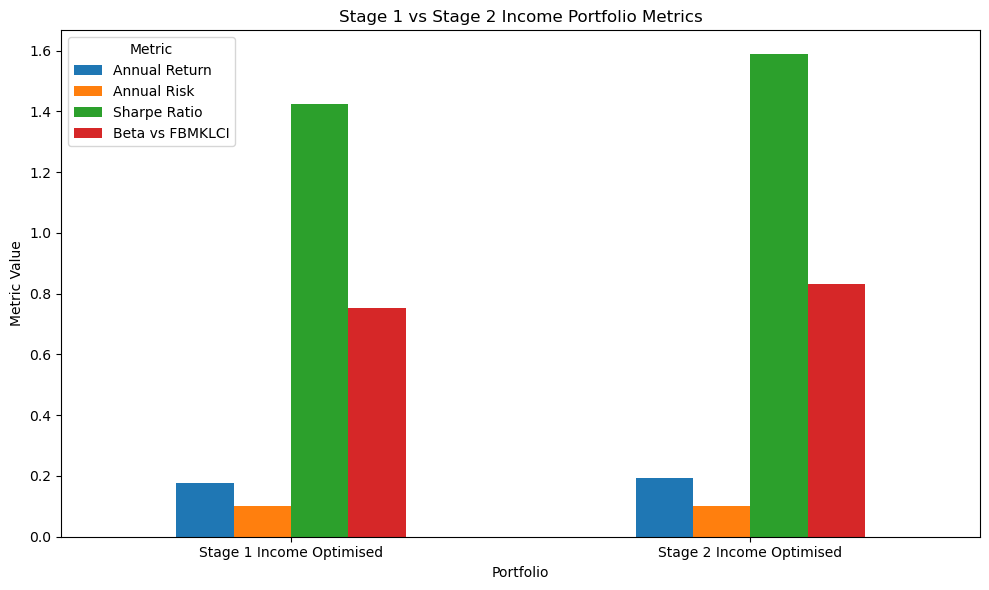

In [33]:
metric_plot_data = portfolio_comparison.copy()

fig, ax = plt.subplots(figsize=(10, 6))

metric_plot_data.plot(kind="bar", ax=ax)

ax.set_title("Stage 1 vs Stage 2 Income Portfolio Metrics")
ax.set_xlabel("Portfolio")
ax.set_ylabel("Metric Value")
ax.legend(title="Metric")
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()

plt.savefig(
    os.path.join(CHART_DIR, "portfolio_metric_comparison.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 3. Optimised Weight Distribution

This chart compares the optimised asset weights in Stage 1 and Stage 2. It helps explain how the asset cap and volatility cap affected portfolio allocation.

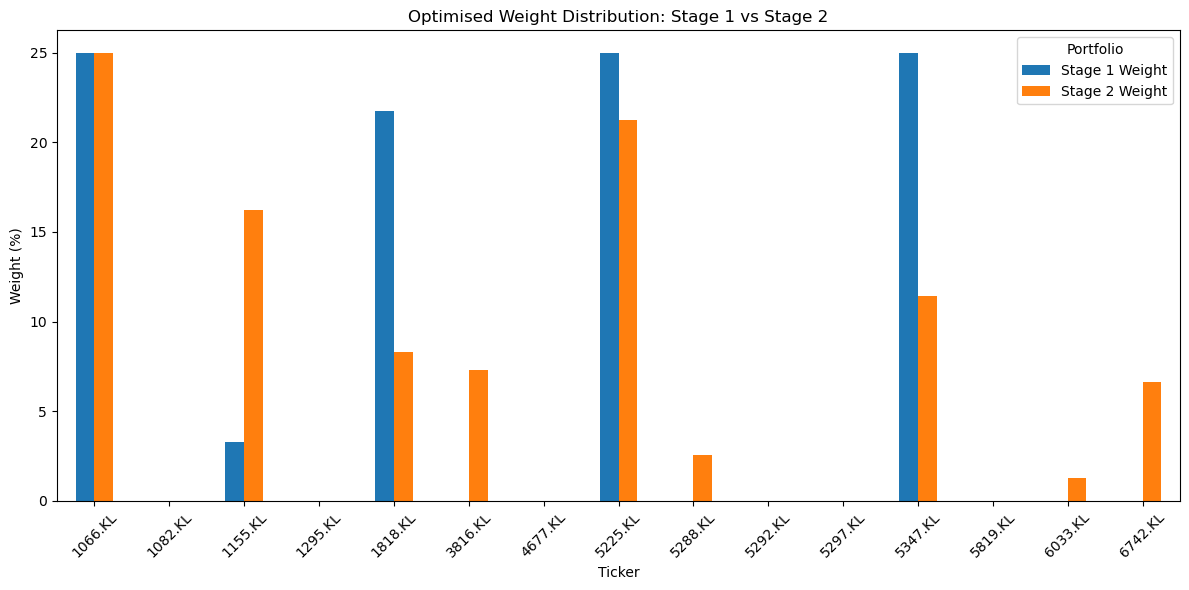

In [34]:
weight_plot_data = weight_comparison.copy() * 100

fig, ax = plt.subplots(figsize=(12, 6))

weight_plot_data.plot(kind="bar", ax=ax)

ax.set_title("Optimised Weight Distribution: Stage 1 vs Stage 2")
ax.set_xlabel("Ticker")
ax.set_ylabel("Weight (%)")
ax.legend(title="Portfolio")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()

plt.savefig(
    os.path.join(CHART_DIR, "weight_distribution_comparison.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 4. MVO versus Benchmark Comparison

This chart compares the income MVO portfolios against equal-weight and inverse-volatility benchmarks. It helps validate whether the optimiser adds value beyond simple allocation methods.

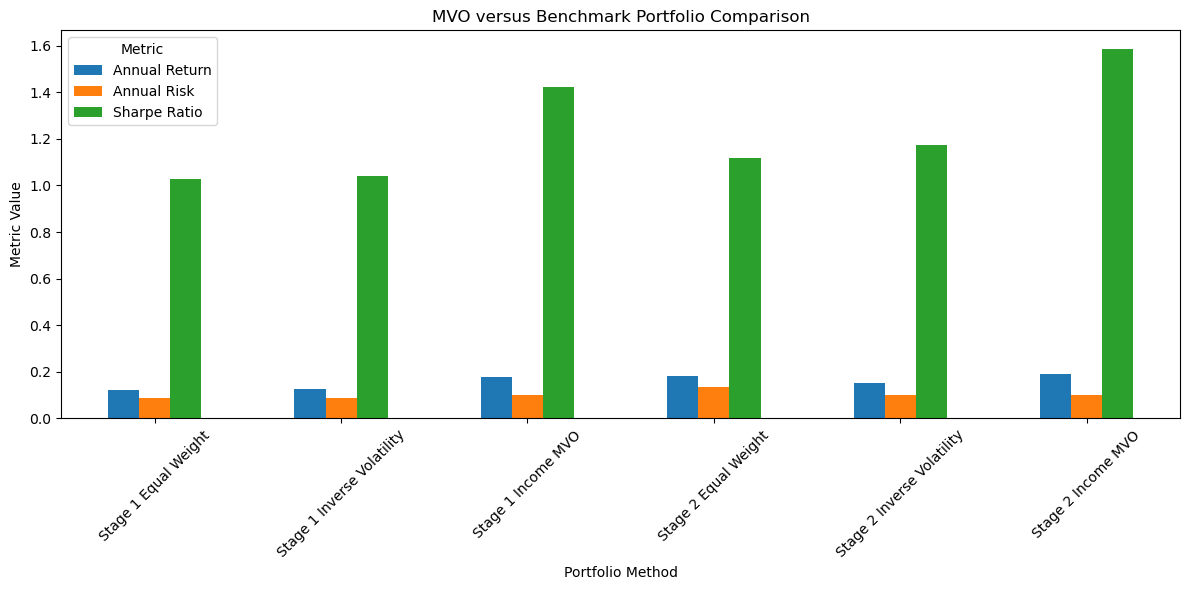

In [35]:
benchmark_plot_data = validation_comparison[["Annual Return", "Annual Risk", "Sharpe Ratio"]].copy()

fig, ax = plt.subplots(figsize=(12, 6))

benchmark_plot_data.plot(kind="bar", ax=ax)

ax.set_title("MVO versus Benchmark Portfolio Comparison")
ax.set_xlabel("Portfolio Method")
ax.set_ylabel("Metric Value")
ax.legend(title="Metric")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()

plt.savefig(
    os.path.join(CHART_DIR, "mvo_vs_benchmark_comparison.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 5. Weight Cap Sensitivity

This chart shows whether the Stage 1 and Stage 2 results remain stable when the maximum asset cap changes from 20% to 25% and 30%.

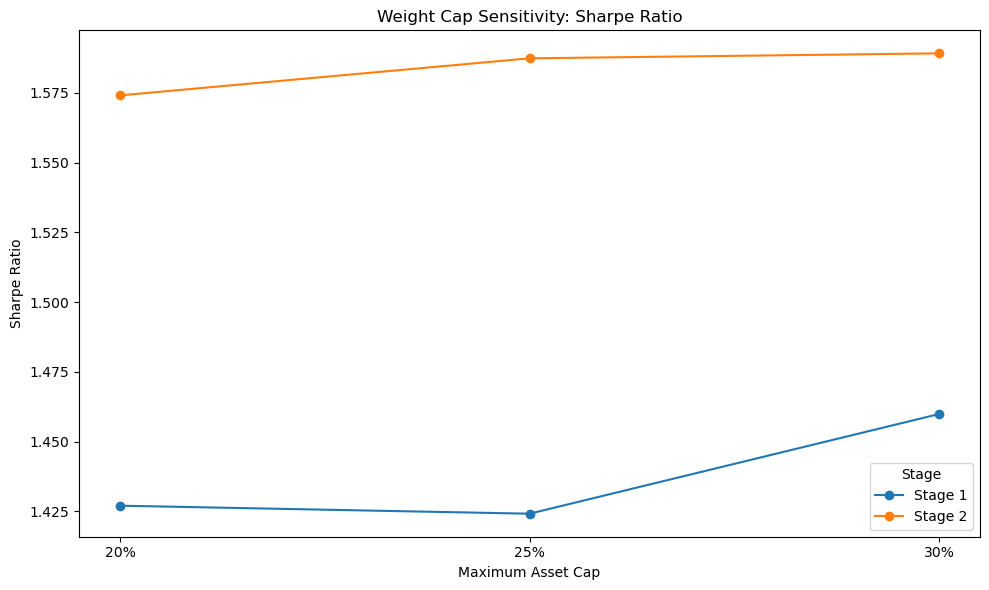

In [36]:
cap_plot_data = cap_sensitivity_table.copy()

# Convert cap labels into ordered categories
cap_plot_data["Max Weight Cap"] = pd.Categorical(
    cap_plot_data["Max Weight Cap"],
    categories=["20%", "25%", "30%"],
    ordered=True
)

fig, ax = plt.subplots(figsize=(10, 6))

for stage in cap_plot_data["Stage"].unique():
    subset = cap_plot_data[cap_plot_data["Stage"] == stage]
    ax.plot(
        subset["Max Weight Cap"].astype(str),
        subset["Sharpe Ratio"],
        marker="o",
        label=stage
    )

ax.set_title("Weight Cap Sensitivity: Sharpe Ratio")
ax.set_xlabel("Maximum Asset Cap")
ax.set_ylabel("Sharpe Ratio")
ax.legend(title="Stage")

plt.tight_layout()

plt.savefig(
    os.path.join(CHART_DIR, "weight_cap_sensitivity_sharpe.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 6. Stage 2 Correlation Heatmap

This heatmap shows the correlation structure of the Stage 2 universe. It helps explain diversification effects and why MVO is needed to account for covariance between assets.

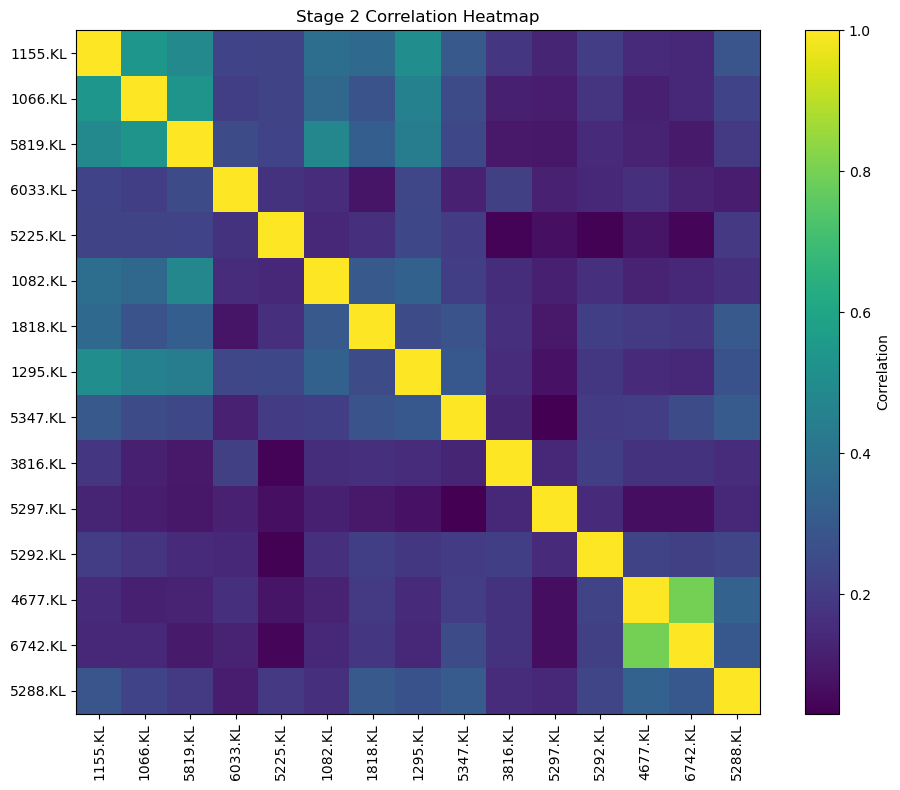

In [37]:
fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(correlation_stage2.values)

ax.set_xticks(np.arange(len(correlation_stage2.columns)))
ax.set_yticks(np.arange(len(correlation_stage2.index)))

ax.set_xticklabels(correlation_stage2.columns, rotation=90)
ax.set_yticklabels(correlation_stage2.index)

ax.set_title("Stage 2 Correlation Heatmap")

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Correlation")

plt.tight_layout()

plt.savefig(
    os.path.join(CHART_DIR, "stage2_correlation_heatmap.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 7. Save Visualisation Summary

The chart filenames are saved to document the visual outputs generated for reporting.

In [38]:
visualisation_summary = pd.DataFrame({
    "Chart": [
        "Portfolio Metric Comparison",
        "Optimised Weight Distribution",
        "MVO versus Benchmark Comparison",
        "Weight Cap Sensitivity",
        "Stage 2 Correlation Heatmap"
    ],
    "File": [
        "portfolio_metric_comparison.png",
        "weight_distribution_comparison.png",
        "mvo_vs_benchmark_comparison.png",
        "weight_cap_sensitivity_sharpe.png",
        "stage2_correlation_heatmap.png"
    ]
})

visualisation_summary.to_csv(
    os.path.join(OUTPUT_DIR, "visualisation_summary.csv"),
    index=False
)

print("Visualisation outputs saved successfully.")

Visualisation outputs saved successfully.
